In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
train_df = pd.read_csv('../data/train.csv')
test_df = pd.read_csv('../data/test.csv')

print('Train Data Shape:',{train_df.shape})
print('Test Data Shape:',{test_df.shape})

train_df.head()

Train Data Shape: {(593994, 13)}
Test Data Shape: {(254569, 12)}


,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0


In [3]:
# Data Types and Null Values
print(train_df.info())

# Null Values Check
print(train_df.isnull().sum())

# Statistics
train_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 593994 entries, 0 to 593993
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    593994 non-null  int64  
 1   annual_income         593994 non-null  float64
 2   debt_to_income_ratio  593994 non-null  float64
 3   credit_score          593994 non-null  int64  
 4   loan_amount           593994 non-null  float64
 5   interest_rate         593994 non-null  float64
 6   gender                593994 non-null  object 
 7   marital_status        593994 non-null  object 
 8   education_level       593994 non-null  object 
 9   employment_status     593994 non-null  object 
 10  loan_purpose          593994 non-null  object 
 11  grade_subgrade        593994 non-null  object 
 12  loan_paid_back        593994 non-null  float64
dtypes: float64(5), int64(2), object(6)
memory usage: 58.9+ MB
None
id                      0
annual_income  

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_paid_back
count,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000
mean,296996.500000,48212.202976,0.120696,680.916009,15020.297629,12.356345,0.798820
std,171471.442235,26711.942078,0.068573,55.424956,6926.530568,2.008959,0.400883
min,0.000000,6002.430000,0.011000,395.000000,500.090000,3.200000,0.000000
25%,148498.250000,27934.400000,0.072000,646.000000,10279.620000,10.990000,1.000000
50%,296996.500000,46557.680000,0.096000,682.000000,15000.220000,12.370000,1.000000
75%,445494.750000,60981.320000,0.156000,719.000000,18858.580000,13.680000,1.000000
max,593993.000000,393381.740000,0.627000,849.000000,48959.950000,20.990000,1.000000


In [26]:
numerical_columns = train_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_columns = train_df.select_dtypes(include=['object']).columns.tolist()

numerical_columns.remove('id')
numerical_columns.remove('loan_paid_back')

print(f"Numerical Columns ({len(numerical_columns)}):")
print(numerical_columns)
print(f"\nCategoric Columns ({len(categorical_columns)}):")
print(categorical_columns)

Numerical Columns (13):
['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount', 'interest_rate', 'income_to_loan_ratio', 'monthly_payment_estimate', 'payment_to_income_ratio', 'high_debt_indicator', 'risk_score', 'subgrade', 'grade_numeric', 'grade_subgrade_numeric']

Categoric Columns (7):
['gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose', 'grade_subgrade', 'grade']


# Exploratory Data Analysis (EDA)

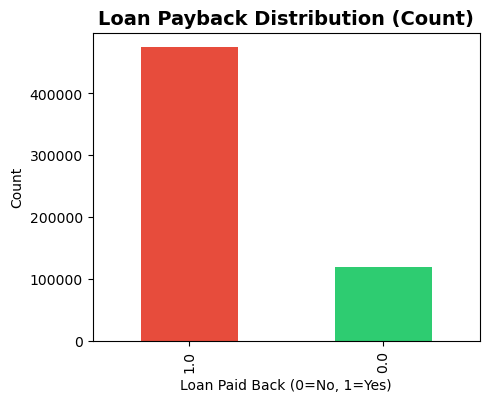

In [47]:
# Target Variable Analysis
plt.figure(figsize=(5, 4))
train_df['loan_paid_back'].value_counts().plot(kind='bar', color=['#e74c3c', '#2ecc71'])
plt.title('Loan Payback Distribution (Count)', fontsize=14, fontweight='bold')
plt.xlabel('Loan Paid Back (0=No, 1=Yes)')
plt.ylabel('Count')
plt.show()

Loan Payback Distribution Analysis: 
The dataset shows a class imbalance with approximately 80% of loans being paid back (1.0) and 20% not paid back (0.0). This 4:1 ratio indicates a moderately imbalanced classification problem. We'll need to use stratified sampling and consider class weights or resampling techniques during model training to ensure the model doesn't simply predict the majority class.

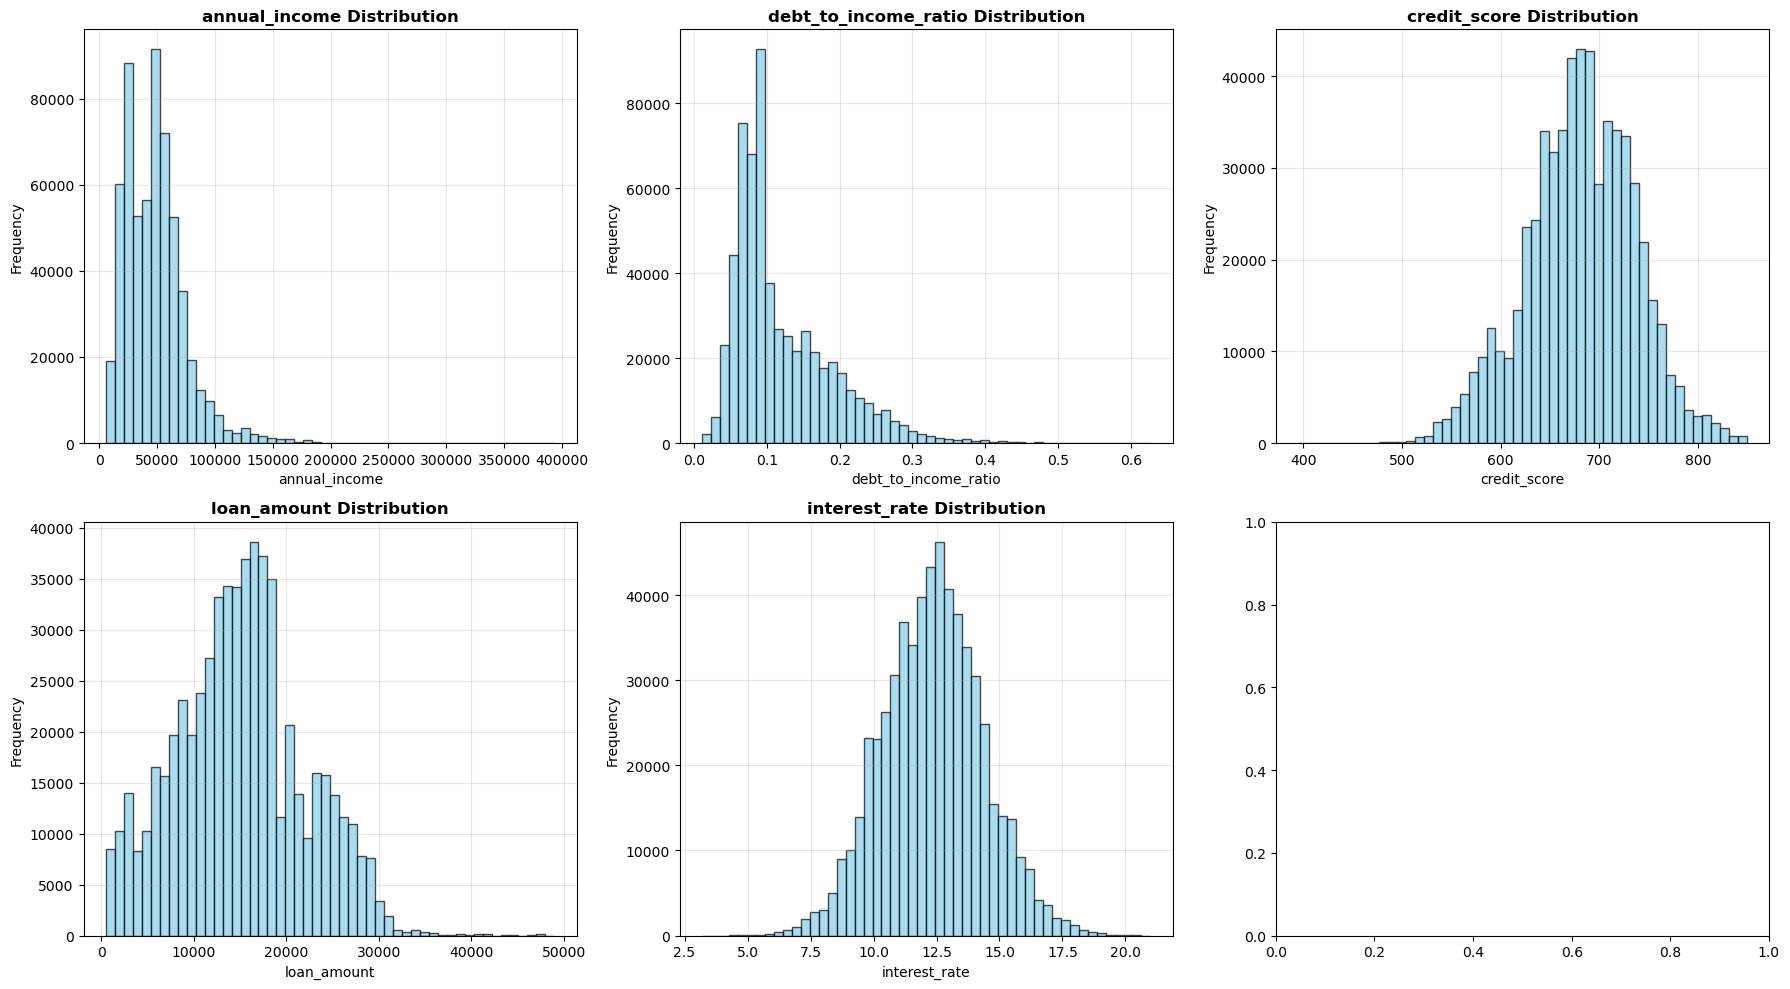

In [48]:
# Numerical Features Distribution
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, col in enumerate(numerical_features):
    axes[idx].hist(train_df[col], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'{col} Distribution', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Numerical Features Analysis:
* Annual Income: Right-skewed distribution with most borrowers earning between 30K-70K. Some high-income outliers exist above 200K.
* Debt-to-Income Ratio: Heavily right-skewed, concentrated between 0.05-0.15. Few borrowers have ratios above 0.4, indicating relatively manageable debt levels for most.
* Credit Score: Nearly normal distribution centered around 680, ranging from 400-850. Good spread across the spectrum.
* Loan Amount: Slightly right-skewed, most loans between 10K-20K. Few large loans above 35K.
* Interest Rate: Bell-shaped distribution centered at 12-13%, ranging from 3% to 21%. Clear relationship expected with credit risk.

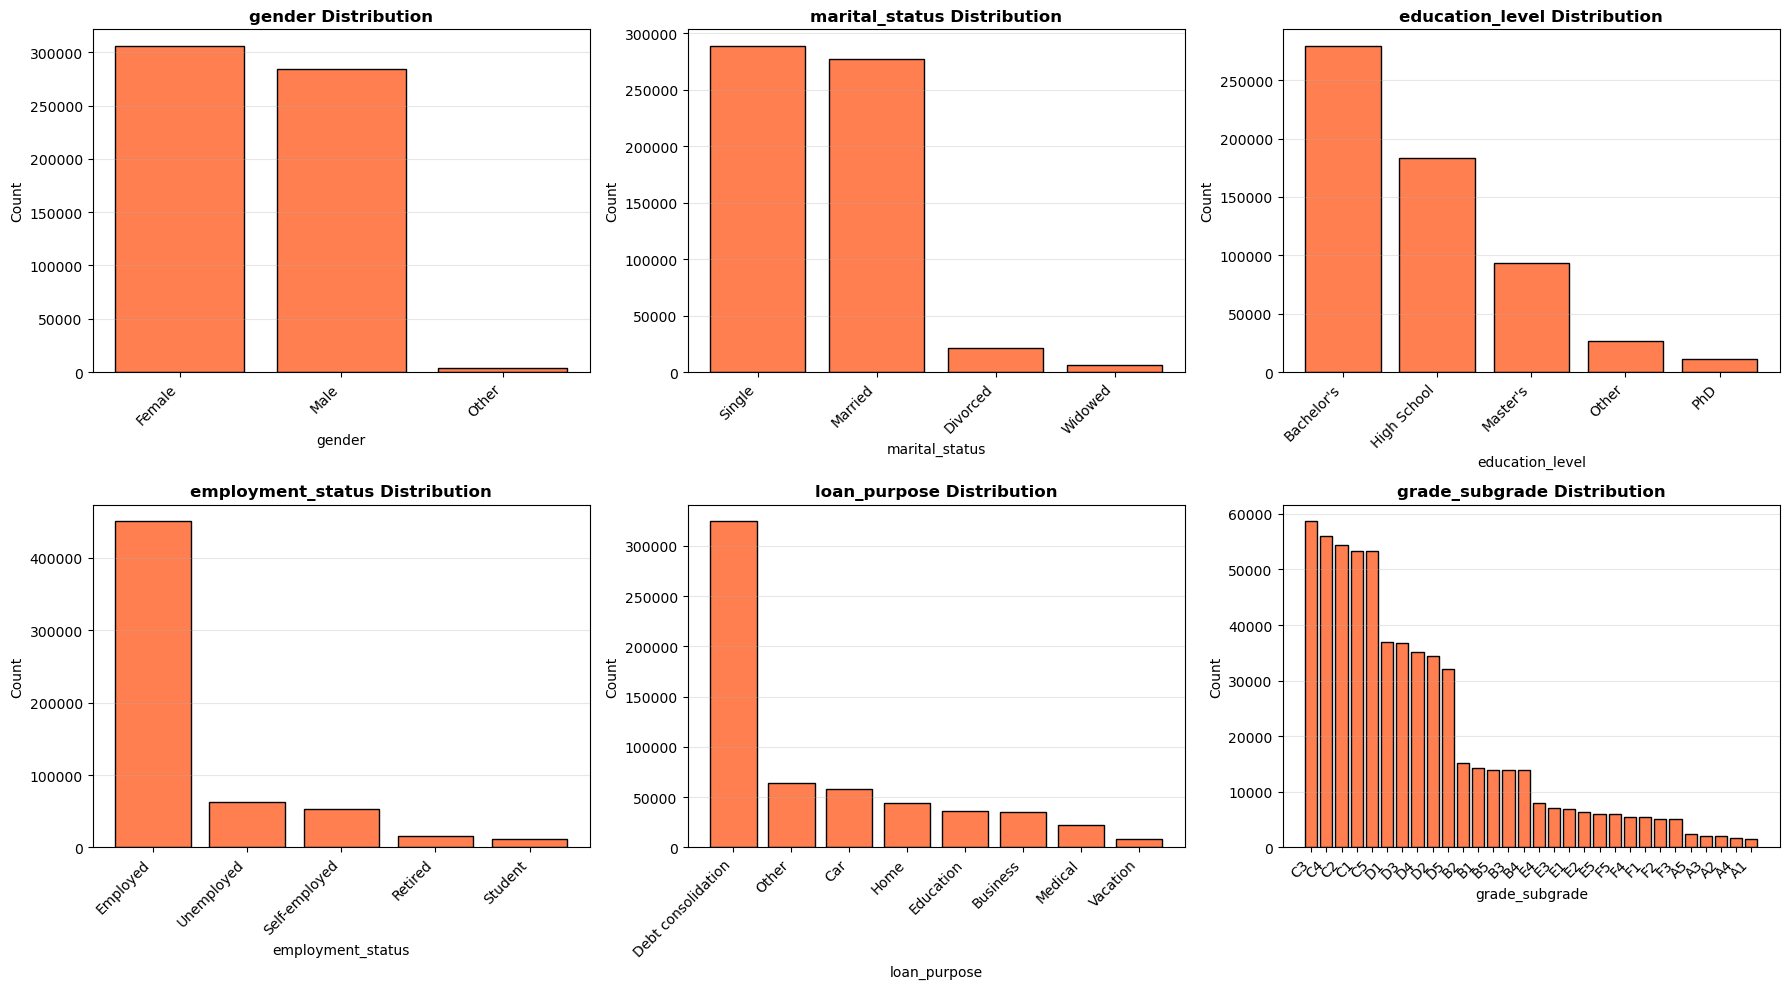

In [49]:
# Categorical Features Distribution
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, col in enumerate(categorical_features):
    value_counts = train_df[col].value_counts()
    axes[idx].bar(range(len(value_counts)), value_counts.values, color='coral', edgecolor='black')
    axes[idx].set_title(f'{col} Distribution', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Count')
    axes[idx].set_xticks(range(len(value_counts)))
    axes[idx].set_xticklabels(value_counts.index, rotation=45, ha='right')
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Categorical Features Distributions Analysis:

* Gender: Nearly balanced (Female ≈ Male ≈ 300K each), with minimal "Other" category.
* Marital Status: Dominated by "Single" and "Married" (≈280K each), very few "Divorced" or "Widowed".
* Education Level: Majority have "Bachelor's" (≈280K), followed by "High School" (≈180K). "Master's", "Other", and "PhD" are minorities.
* Employment Status: Heavily imbalanced - "Employed" dominates (≈460K), while "Unemployed", "Self-employed", "Retired", and "Student" are very small groups.
* Loan Purpose: "Debt Consolidation" is by far the most common (≈320K), followed by much smaller categories like "Other", "Car", "Home", "Education", "Business", "Medical", and "Vacation".
* Grade Subgrade: 35 distinct grades showing a relatively smooth distribution from high grades (A1-A5) to low grades (F1-G5), with most loans concentrated in B-D range.

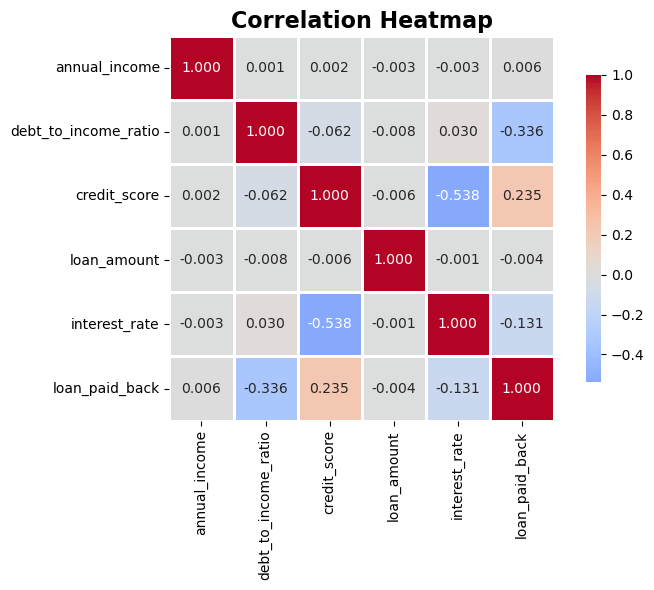

In [50]:
# Correlation
correlation_data = train_df[numerical_features + ['loan_paid_back']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_data, annot=True, fmt='.3f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Correlation Heatmap Analysis:
Strong Correlations with Target (loan_paid_back):

* debt_to_income_ratio: -0.336 (strongest negative) - Higher debt burden = lower payback probability
* credit_score: +0.235 (strongest positive) - Better credit = higher payback probability
* interest_rate: -0.131 (moderate negative) - Higher rates = lower payback probability

Inter-feature Correlations:

* credit_score ↔ interest_rate: -0.538 (strong negative) - Expected: better credit gets lower rates
* Other correlations are weak (<0.1), indicating features are relatively independent

## 5. Target vs Numerical Features (Boxplot)

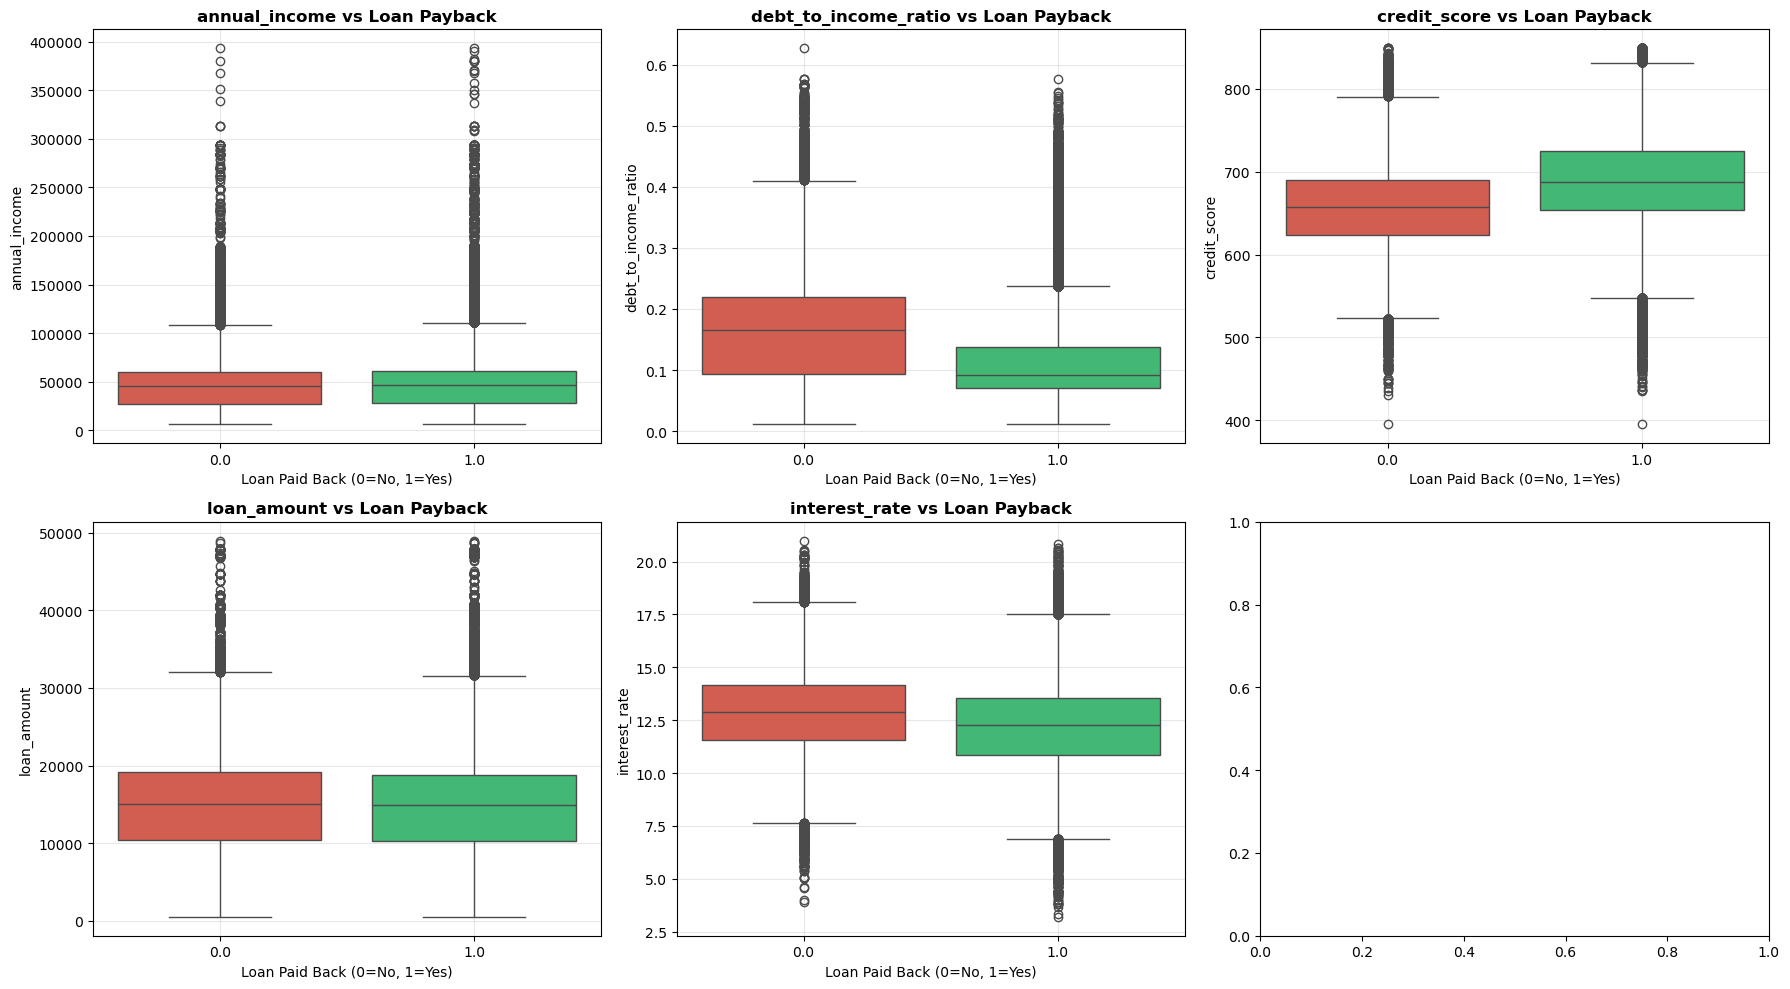

In [51]:
# Target değişkene göre sayısal değişkenlerin karşılaştırması
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, col in enumerate(numerical_features):
    sns.boxplot(data=train_df, x='loan_paid_back', y=col, ax=axes[idx], palette=['#e74c3c', '#2ecc71'])
    axes[idx].set_title(f'{col} vs Loan Payback', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Loan Paid Back (0=No, 1=Yes)')
    axes[idx].set_ylabel(col)
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Numerical Features vs Loan Payback Analysis:

* Annual Income: Minimal difference between paid (1.0) and not paid (0.0) groups. Both medians around 45K-50K. Not a strong discriminator alone.
* Debt-to-Income Ratio: Clear separation! Non-payers (0.0) have noticeably higher median (~0.15) vs payers (~0.10). This confirms the correlation finding.
* Credit Score: Significant difference - payers have median ~680-700, non-payers ~640-660. Strong predictive signal.
* Loan Amount: Slight difference with non-payers having marginally higher median loan amounts. Weak signal.
* Interest Rate: Clear separation - non-payers face higher rates (median ~13.5%) vs payers (~11.5%), reflecting their higher risk profile.

# Feature Engineering

In [24]:
def create_new_features(df):
    # Income to loan ratio
    df['income_to_loan_ratio'] = df['annual_income'] / (df['loan_amount'] + 1)
    
    # Monthly payment estimation
    df['monthly_payment_estimate'] = (df['loan_amount'] * (df['interest_rate']/100)) / 12
    
    # Payment to income ratio
    df['payment_to_income_ratio'] = (df['monthly_payment_estimate'] * 12) / (df['annual_income'] + 1)
    
    # Credit utilization indicator
    df['high_debt_indicator'] = (df['debt_to_income_ratio'] > 0.36).astype(int)
    
    # Risk score combination
    df['risk_score'] = (
        (df['debt_to_income_ratio'] * 100) - 
        (df['credit_score'] / 10) + 
        (df['interest_rate'])
    )
    
    return df

train_df = create_new_features(train_df.copy())
test_df = create_new_features(test_df.copy())

print('Train Data Shape:',{train_df.shape})
print('Test Data Shape:',{test_df.shape})

Train Data Shape: {(593994, 18)}
Test Data Shape: {(254569, 17)}


In [25]:
def grade_subgrade_parsing(df):
    df['grade'] = df['grade_subgrade'].str[0]

    df['subgrade'] = df['grade_subgrade'].str[1:].astype(int)

    # Convert grade to numeric feature
    grade_mapping = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
    df['grade_numeric'] = df['grade'].map(grade_mapping)
    
    # Combined risk score (grade * 5 + subgrade)
    df['grade_subgrade_numeric'] = df['grade_numeric'] * 5 + df['subgrade']

    return df

train_df = grade_subgrade_parsing(train_df)
test_df = grade_subgrade_parsing(test_df)

print('Train Data Shape:',{train_df.shape})
print('Test Data Shape:',{test_df.shape})

print(train_df.head())

Train Data Shape: {(593994, 22)}
Test Data Shape: {(254569, 21)}
   id  annual_income  debt_to_income_ratio  credit_score  loan_amount  \
0   0       29367.99                 0.084           736      2528.42   
1   1       22108.02                 0.166           636      4593.10   
2   2       49566.20                 0.097           694     17005.15   
3   3       46858.25                 0.065           533      4682.48   
4   4       25496.70                 0.053           665     12184.43   

   interest_rate  gender marital_status education_level employment_status  \
0          13.67  Female         Single     High School     Self-employed   
1          12.92    Male        Married        Master's          Employed   
2           9.76    Male         Single     High School          Employed   
3          16.10  Female         Single     High School          Employed   
4          10.21    Male        Married     High School          Employed   

   ... loan_paid_back income_to_l

In [28]:
from sklearn.preprocessing import LabelEncoder

def encode_categorical_features(train_df, test_df):
    
    categorical_columns = ['gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose', 'grade']
    
    label_encoders = {}
    
    for col in categorical_columns:
        le = LabelEncoder()
        
        combined = pd.concat([train_df[col], test_df[col]], axis=0)
        le.fit(combined)
        
        train_df[col + '_encoded'] = le.transform(train_df[col])
        test_df[col + '_encoded'] = le.transform(test_df[col])
        
        label_encoders[col] = le
    
    return train_df, test_df, label_encoders

train_df, test_df, encoders = encode_categorical_features(train_df, test_df)

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")

Train shape: (593994, 28)
Test shape: (254569, 27)


In [29]:
train_df.head()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,...,grade,subgrade,grade_numeric,grade_subgrade_numeric,gender_encoded,marital_status_encoded,education_level_encoded,employment_status_encoded,loan_purpose_encoded,grade_encoded
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,...,C,3,3,18,0,2,1,2,6,2
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,...,D,3,4,23,1,1,2,0,2,3
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,...,C,5,3,20,1,2,1,0,2,2
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,...,F,1,6,31,0,2,1,0,2,5
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,...,D,1,4,21,1,1,1,0,6,3


In [30]:
columns_to_drop = ['id', 'gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose', 'grade', 'grade_subgrade']

X_train = train_df.drop(columns=columns_to_drop + ['loan_paid_back'])

y_train = train_df['loan_paid_back']

X_test = test_df.drop(columns=columns_to_drop)

test_ids = test_df['id']

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (593994, 19)
y_train shape: (593994,)
X_test shape: (254569, 19)


In [32]:
# Train-Validation Split

from sklearn.model_selection import train_test_split

X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train, 
    y_train, 
    test_size=0.2,  # %20'si validation
    stratify=y_train,  # Class balance'ı koru
    random_state=42  # Reproducibility
)

print(f"Training set: {X_train_split.shape}")
print(f"Validation set: {X_val_split.shape}")
print(f"Test set (submission): {X_test.shape}")

print("Training target Dist:")
print(y_train_split.value_counts(normalize=True))
print("Validation target Dist:")
print(y_val_split.value_counts(normalize=True))

Training set: (475195, 19)
Validation set: (118799, 19)
Test set (submission): (254569, 19)
Training target Dist:
loan_paid_back
1.0    0.798819
0.0    0.201181
Name: proportion, dtype: float64
Validation target Dist:
loan_paid_back
1.0    0.79882
0.0    0.20118
Name: proportion, dtype: float64


# Model Preparation

In [ ]:
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report

params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.9,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1,
    'random_state': 42,
    'n_jobs': -1
}

train_data = lgb.Dataset(X_train_split, label=y_train_split)
val_data = lgb.Dataset(X_val_split, label=y_val_split, reference=train_data)

model = lgb.train(
    params,
    train_data,
    num_boost_round=1000,
    valid_sets=[train_data, val_data],
    valid_names=['train', 'valid'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=100)
    ]
)

y_val_pred_proba = model.predict(X_val_split, num_iteration=model.best_iteration)
y_val_pred = (y_val_pred_proba > 0.5).astype(int)

val_auc = roc_auc_score(y_val_split, y_val_pred_proba)
val_acc = accuracy_score(y_val_split, y_val_pred)

print("\n" + "="*50)
print("📊 BASELINE MODEL RESULTS")
print("="*50)
print(f"Validation AUC: {val_auc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Best iteration: {model.best_iteration}")
print("\n📈 Classification Report:")
print(classification_report(y_val_split, y_val_pred))

🚀 Model eğitimi başlıyor...
Training until validation scores don't improve for 50 rounds
[100]	train's auc: 0.918084	valid's auc: 0.916363
[200]	train's auc: 0.922463	valid's auc: 0.91927
[300]	train's auc: 0.92517	valid's auc: 0.919986
[400]	train's auc: 0.927337	valid's auc: 0.920247
[500]	train's auc: 0.929505	valid's auc: 0.920708
[600]	train's auc: 0.9315	valid's auc: 0.920965
[700]	train's auc: 0.933245	valid's auc: 0.921173
Early stopping, best iteration is:
[728]	train's auc: 0.933717	valid's auc: 0.921222

📊 BASELINE MODEL RESULTS
Validation AUC: 0.9212
Validation Accuracy: 0.9055
Best iteration: 728

📈 Classification Report:
              precision    recall  f1-score   support

         0.0       0.88      0.61      0.72     23900
         1.0       0.91      0.98      0.94     94899

    accuracy                           0.91    118799
   macro avg       0.89      0.80      0.83    118799
weighted avg       0.90      0.91      0.90    118799



In [34]:
# Model Training - Part 2: LightGBM with Class Weights

# Class weight hesapla (imbalance için)
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_split),
    y=y_train_split
)

print(f"Class weights: {class_weights}")
print(f"Class 0 (Not Paid) weight: {class_weights[0]:.2f}")
print(f"Class 1 (Paid Back) weight: {class_weights[1]:.2f}")

# İyileştirilmiş parametreler + class weight
params_improved = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'num_leaves': 50,  # Artırdık (daha complex)
    'learning_rate': 0.03,  # Azalttık (daha stable)
    'feature_fraction': 0.8,
    'bagging_fraction': 0.7,
    'bagging_freq': 5,
    'min_child_samples': 20,
    'scale_pos_weight': class_weights[0] / class_weights[1],  # Class imbalance için
    'verbose': -1,
    'random_state': 42,
    'n_jobs': -1
}

# Model eğit
print("\n🚀 İyileştirilmiş model eğitimi başlıyor...")
model_improved = lgb.train(
    params_improved,
    train_data,
    num_boost_round=2000,
    valid_sets=[train_data, val_data],
    valid_names=['train', 'valid'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=100),
        lgb.log_evaluation(period=100)
    ]
)

# Validation predictions
y_val_pred_proba_imp = model_improved.predict(X_val_split, num_iteration=model_improved.best_iteration)
y_val_pred_imp = (y_val_pred_proba_imp > 0.5).astype(int)

# Evaluation
val_auc_imp = roc_auc_score(y_val_split, y_val_pred_proba_imp)
val_acc_imp = accuracy_score(y_val_split, y_val_pred_imp)

print("\n" + "="*50)
print("📊 IMPROVED MODEL RESULTS")
print("="*50)
print(f"Validation AUC: {val_auc_imp:.4f} (Baseline: {val_auc:.4f})")
print(f"Validation Accuracy: {val_acc_imp:.4f} (Baseline: {val_acc:.4f})")
print(f"Best iteration: {model_improved.best_iteration}")
print("\n📈 Classification Report:")
print(classification_report(y_val_split, y_val_pred_imp))

Class weights: [2.4853295  0.62592368]
Class 0 (Not Paid) weight: 2.49
Class 1 (Paid Back) weight: 0.63

🚀 İyileştirilmiş model eğitimi başlıyor...
Training until validation scores don't improve for 100 rounds
[100]	train's auc: 0.914311	valid's auc: 0.91301
[200]	train's auc: 0.918629	valid's auc: 0.91649
[300]	train's auc: 0.922221	valid's auc: 0.91862
[400]	train's auc: 0.92457	valid's auc: 0.919512
[500]	train's auc: 0.926813	valid's auc: 0.919969
[600]	train's auc: 0.928592	valid's auc: 0.920322
[700]	train's auc: 0.93022	valid's auc: 0.920493
[800]	train's auc: 0.931981	valid's auc: 0.920607
[900]	train's auc: 0.933475	valid's auc: 0.920627
[1000]	train's auc: 0.934883	valid's auc: 0.920811
[1100]	train's auc: 0.936332	valid's auc: 0.920872
[1200]	train's auc: 0.937781	valid's auc: 0.920903
[1300]	train's auc: 0.939343	valid's auc: 0.920983
[1400]	train's auc: 0.940739	valid's auc: 0.921016
[1500]	train's auc: 0.942053	valid's auc: 0.921002
Early stopping, best iteration is:
[146

In [35]:
# Model Training - Part 3: Threshold Tuning

from sklearn.metrics import precision_recall_curve, f1_score

# Baseline model'i kullan (daha iyi AUC'ye sahip)
# Farklı threshold'lar dene
thresholds = np.arange(0.3, 0.7, 0.05)

results = []
for thresh in thresholds:
    y_pred_thresh = (y_val_pred_proba > thresh).astype(int)
    
    # Metrics
    acc = accuracy_score(y_val_split, y_pred_thresh)
    
    # Class 0 metrics
    class_0_mask = y_val_split == 0
    class_0_recall = (y_pred_thresh[class_0_mask] == 0).sum() / class_0_mask.sum()
    
    # Class 1 metrics  
    class_1_mask = y_val_split == 1
    class_1_recall = (y_pred_thresh[class_1_mask] == 1).sum() / class_1_mask.sum()
    
    results.append({
        'threshold': thresh,
        'accuracy': acc,
        'class_0_recall': class_0_recall,
        'class_1_recall': class_1_recall
    })

# DataFrame'e çevir
results_df = pd.DataFrame(results)
print("🎯 Threshold Tuning Results:")
print(results_df.to_string(index=False))

# En iyi threshold'u seç (Class 0 recall'ü maksimize eden)
best_idx = results_df['class_0_recall'].idxmax()
best_threshold = results_df.loc[best_idx, 'threshold']

print(f"\n✅ En iyi threshold: {best_threshold}")
print(f"   Class 0 Recall: {results_df.loc[best_idx, 'class_0_recall']:.4f}")
print(f"   Accuracy: {results_df.loc[best_idx, 'accuracy']:.4f}")

# Best threshold ile final predictions
y_val_pred_final = (y_val_pred_proba > best_threshold).astype(int)

print("\n" + "="*50)
print("📊 OPTIMIZED THRESHOLD MODEL")
print("="*50)
print(f"Threshold: {best_threshold}")
print(f"Validation AUC: {val_auc:.4f}")
print("\n📈 Classification Report:")
print(classification_report(y_val_split, y_val_pred_final))

🎯 Threshold Tuning Results:
 threshold  accuracy  class_0_recall  class_1_recall
      0.30  0.900597        0.531590        0.993530
      0.35  0.902070        0.545272        0.991928
      0.40  0.903661        0.563473        0.989336
      0.45  0.905075        0.586653        0.985269
      0.50  0.905538        0.614226        0.978904
      0.55  0.905513        0.644854        0.971159
      0.60  0.903467        0.673598        0.961359
      0.65  0.899553        0.701046        0.949546

✅ En iyi threshold: 0.6499999999999999
   Class 0 Recall: 0.7010
   Accuracy: 0.8996

📊 OPTIMIZED THRESHOLD MODEL
Threshold: 0.6499999999999999
Validation AUC: 0.9212

📈 Classification Report:
              precision    recall  f1-score   support

         0.0       0.78      0.70      0.74     23900
         1.0       0.93      0.95      0.94     94899

    accuracy                           0.90    118799
   macro avg       0.85      0.83      0.84    118799
weighted avg       0.90      

📊 Top 15 Most Important Features:
                  feature   importance
employment_status_encoded 1.399251e+06
               risk_score 4.087327e+05
     debt_to_income_ratio 1.661351e+05
             credit_score 6.381758e+04
            interest_rate 1.999364e+04
              loan_amount 1.842379e+04
            annual_income 1.765653e+04
  payment_to_income_ratio 9.558250e+03
 monthly_payment_estimate 9.521389e+03
     income_to_loan_ratio 9.325928e+03
   grade_subgrade_numeric 7.204970e+03
            grade_numeric 4.495314e+03
     loan_purpose_encoded 4.486944e+03
                 subgrade 3.504784e+03
  education_level_encoded 3.435961e+03


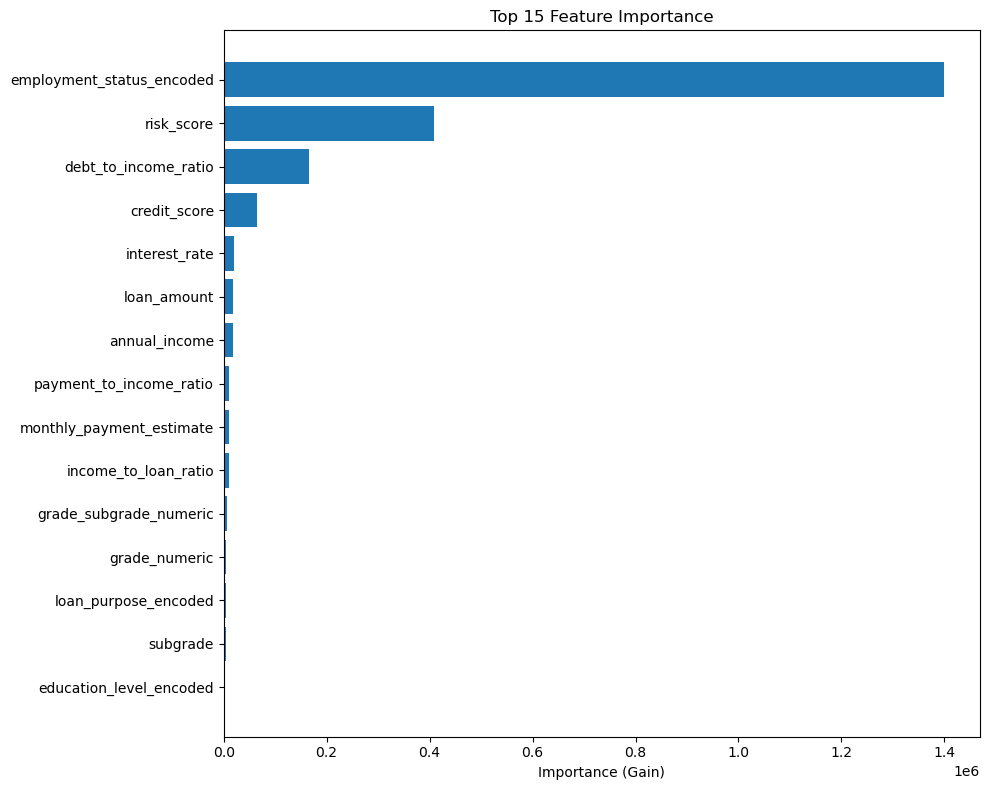


🎯 FINAL MODEL SUMMARY
Model: LightGBM with optimized threshold (0.65)
Validation AUC: 0.9212
Validation Accuracy: 0.8996
Class 0 Recall: 0.7010
Best Iteration: 728


In [36]:
# Final Steps - Part 1: Feature Importance

import matplotlib.pyplot as plt

# Feature importance çıkar
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=False)

print("📊 Top 15 Most Important Features:")
print(feature_importance.head(15).to_string(index=False))

# Visualize
plt.figure(figsize=(10, 8))
top_features = feature_importance.head(15)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Importance (Gain)')
plt.title('Top 15 Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("🎯 FINAL MODEL SUMMARY")
print("="*50)
print(f"Model: LightGBM with optimized threshold (0.65)")
print(f"Validation AUC: {val_auc:.4f}")
print(f"Validation Accuracy: {results_df.loc[best_idx, 'accuracy']:.4f}")
print(f"Class 0 Recall: {results_df.loc[best_idx, 'class_0_recall']:.4f}")
print(f"Best Iteration: {model.best_iteration}")

In [37]:
# Final Steps - Part 2: Test Predictions & Submission

# Test setine tahmin yap
print("🚀 Test predictions yapılıyor...")
test_predictions_proba = model.predict(X_test, num_iteration=model.best_iteration)

# Optimized threshold uygula (0.65)
test_predictions = (test_predictions_proba > best_threshold).astype(int)

# Submission dosyası oluştur
submission = pd.DataFrame({
    'id': test_ids,
    'loan_paid_back': test_predictions
})

print("\n📊 Submission Preview:")
print(submission.head(10))
print(f"\nSubmission shape: {submission.shape}")
print(f"\nPrediction distribution:")
print(submission['loan_paid_back'].value_counts())
print(f"\nPredicted payback rate: {submission['loan_paid_back'].mean():.2%}")

# CSV olarak kaydet
submission.to_csv('submission.csv', index=False)
print("\n✅ Submission dosyası kaydedildi: submission.csv")

# Özet
print("\n" + "="*60)
print("🎯 FINAL SUBMISSION SUMMARY")
print("="*60)
print(f"Model: LightGBM (Baseline) with Threshold Optimization")
print(f"Threshold: {best_threshold}")
print(f"Validation AUC: {val_auc:.4f}")
print(f"Validation Accuracy: {results_df.loc[best_idx, 'accuracy']:.4f}")
print(f"Class 0 Recall: {results_df.loc[best_idx, 'class_0_recall']:.4f}")
print(f"Class 1 Recall: {results_df.loc[best_idx, 'class_1_recall']:.4f}")
print(f"Test predictions: {len(test_predictions)} samples")
print("="*60)

🚀 Test predictions yapılıyor...

📊 Submission Preview:
       id  loan_paid_back
0  593994               1
1  593995               1
2  593996               0
3  593997               1
4  593998               1
5  593999               1
6  594000               1
7  594001               1
8  594002               1
9  594003               0

Submission shape: (254569, 2)

Prediction distribution:
loan_paid_back
1    208812
0     45757
Name: count, dtype: int64

Predicted payback rate: 82.03%

✅ Submission dosyası kaydedildi: submission.csv

🎯 FINAL SUBMISSION SUMMARY
Model: LightGBM (Baseline) with Threshold Optimization
Threshold: 0.6499999999999999
Validation AUC: 0.9212
Validation Accuracy: 0.8996
Class 0 Recall: 0.7010
Class 1 Recall: 0.9495
Test predictions: 254569 samples


In [38]:
# Model Training - Part 4: XGBoost

import xgboost as xgb
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report

# Class weight hesapla
scale_pos_weight = (y_train_split == 0).sum() / (y_train_split == 1).sum()

# XGBoost parametreleri
xgb_params = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'max_depth': 7,
    'learning_rate': 0.03,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 5,
    'gamma': 0.1,
    'scale_pos_weight': scale_pos_weight,
    'random_state': 42,
    'n_jobs': -1,
    'tree_method': 'hist'
}

# DMatrix oluştur
dtrain = xgb.DMatrix(X_train_split, label=y_train_split)
dval = xgb.DMatrix(X_val_split, label=y_val_split)
dtest = xgb.DMatrix(X_test)

# Model eğit
print("🚀 XGBoost model eğitimi başlıyor...")
evals = [(dtrain, 'train'), (dval, 'valid')]

xgb_model = xgb.train(
    xgb_params,
    dtrain,
    num_boost_round=2000,
    evals=evals,
    early_stopping_rounds=100,
    verbose_eval=100
)

# Validation predictions
y_val_pred_proba_xgb = xgb_model.predict(dval, iteration_range=(0, xgb_model.best_iteration))

# Threshold tuning için
thresholds_xgb = np.arange(0.3, 0.7, 0.05)
results_xgb = []

for thresh in thresholds_xgb:
    y_pred_thresh = (y_val_pred_proba_xgb > thresh).astype(int)
    acc = accuracy_score(y_val_split, y_pred_thresh)
    class_0_mask = y_val_split == 0
    class_0_recall = (y_pred_thresh[class_0_mask] == 0).sum() / class_0_mask.sum()
    class_1_mask = y_val_split == 1
    class_1_recall = (y_pred_thresh[class_1_mask] == 1).sum() / class_1_mask.sum()
    
    results_xgb.append({
        'threshold': thresh,
        'accuracy': acc,
        'class_0_recall': class_0_recall,
        'class_1_recall': class_1_recall
    })

results_xgb_df = pd.DataFrame(results_xgb)
print("\n🎯 XGBoost Threshold Tuning Results:")
print(results_xgb_df.to_string(index=False))

# En iyi threshold
best_idx_xgb = results_xgb_df['class_0_recall'].idxmax()
best_threshold_xgb = results_xgb_df.loc[best_idx_xgb, 'threshold']

# Final predictions
y_val_pred_final_xgb = (y_val_pred_proba_xgb > best_threshold_xgb).astype(int)
val_auc_xgb = roc_auc_score(y_val_split, y_val_pred_proba_xgb)

print("\n" + "="*50)
print("📊 XGBOOST MODEL RESULTS")
print("="*50)
print(f"Best Threshold: {best_threshold_xgb}")
print(f"Validation AUC: {val_auc_xgb:.4f}")
print(f"Validation Accuracy: {results_xgb_df.loc[best_idx_xgb, 'accuracy']:.4f}")
print(f"Class 0 Recall: {results_xgb_df.loc[best_idx_xgb, 'class_0_recall']:.4f}")
print("\n📈 Classification Report:")
print(classification_report(y_val_split, y_val_pred_final_xgb))

# Test predictions
test_predictions_proba_xgb = xgb_model.predict(dtest, iteration_range=(0, xgb_model.best_iteration))
test_predictions_xgb = (test_predictions_proba_xgb > best_threshold_xgb).astype(int)

# XGBoost submission
submission_xgb = pd.DataFrame({
    'id': test_ids,
    'loan_paid_back': test_predictions_xgb
})

submission_xgb.to_csv('submission_xgboost.csv', index=False)
print("\n✅ XGBoost submission kaydedildi: submission_xgboost.csv")
print(f"Predicted payback rate: {submission_xgb['loan_paid_back'].mean():.2%}")

🚀 XGBoost model eğitimi başlıyor...
[0]	train-auc:0.91043	valid-auc:0.90885
[100]	train-auc:0.91753	valid-auc:0.91492
[200]	train-auc:0.92116	valid-auc:0.91709
[300]	train-auc:0.92395	valid-auc:0.91822
[400]	train-auc:0.92666	valid-auc:0.91895
[500]	train-auc:0.92907	valid-auc:0.91949
[600]	train-auc:0.93114	valid-auc:0.91985
[700]	train-auc:0.93296	valid-auc:0.92006
[800]	train-auc:0.93467	valid-auc:0.92023
[900]	train-auc:0.93633	valid-auc:0.92033
[1000]	train-auc:0.93783	valid-auc:0.92036
[1100]	train-auc:0.93927	valid-auc:0.92033
[1103]	train-auc:0.93932	valid-auc:0.92032

🎯 XGBoost Threshold Tuning Results:
 threshold  accuracy  class_0_recall  class_1_recall
      0.30  0.900917        0.678452        0.956944
      0.35  0.896161        0.710460        0.942929
      0.40  0.889435        0.735774        0.928134
      0.45  0.880386        0.761590        0.910305
      0.50  0.868854        0.786276        0.889651
      0.55  0.851455        0.811841        0.861432
      0.6

In [39]:
# Ensemble - Part 1: Weighted Voting

print("🔀 Ensemble model oluşturuluyor...")

# İki modelin probability tahminlerini ağırlıklı ortala
# LightGBM daha iyi AUC'ye sahip, ona daha fazla ağırlık verelim
lgb_weight = 0.7
xgb_weight = 0.3

# Validation ensemble
y_val_ensemble_proba = (lgb_weight * y_val_pred_proba + 
                        xgb_weight * y_val_pred_proba_xgb)

# Threshold tuning
results_ensemble = []
for thresh in thresholds:
    y_pred_thresh = (y_val_ensemble_proba > thresh).astype(int)
    acc = accuracy_score(y_val_split, y_pred_thresh)
    class_0_mask = y_val_split == 0
    class_0_recall = (y_pred_thresh[class_0_mask] == 0).sum() / class_0_mask.sum()
    class_1_mask = y_val_split == 1
    class_1_recall = (y_pred_thresh[class_1_mask] == 1).sum() / class_1_mask.sum()
    
    results_ensemble.append({
        'threshold': thresh,
        'accuracy': acc,
        'class_0_recall': class_0_recall,
        'class_1_recall': class_1_recall
    })

results_ensemble_df = pd.DataFrame(results_ensemble)
print("\n🎯 Ensemble Threshold Tuning:")
print(results_ensemble_df.to_string(index=False))

# En iyi threshold
best_idx_ens = results_ensemble_df['class_0_recall'].idxmax()
best_threshold_ens = results_ensemble_df.loc[best_idx_ens, 'threshold']

y_val_pred_final_ens = (y_val_ensemble_proba > best_threshold_ens).astype(int)
val_auc_ens = roc_auc_score(y_val_split, y_val_ensemble_proba)

print("\n" + "="*50)
print("📊 ENSEMBLE MODEL RESULTS")
print("="*50)
print(f"Weights: LightGBM={lgb_weight}, XGBoost={xgb_weight}")
print(f"Best Threshold: {best_threshold_ens}")
print(f"Validation AUC: {val_auc_ens:.4f}")
print(f"Validation Accuracy: {results_ensemble_df.loc[best_idx_ens, 'accuracy']:.4f}")
print(f"Class 0 Recall: {results_ensemble_df.loc[best_idx_ens, 'class_0_recall']:.4f}")
print("\n📈 Classification Report:")
print(classification_report(y_val_split, y_val_pred_final_ens))

# Test ensemble predictions
test_ensemble_proba = (lgb_weight * test_predictions_proba + 
                       xgb_weight * test_predictions_proba_xgb)
test_predictions_ens = (test_ensemble_proba > best_threshold_ens).astype(int)

# Ensemble submission
submission_ensemble = pd.DataFrame({
    'id': test_ids,
    'loan_paid_back': test_predictions_ens
})

submission_ensemble.to_csv('submission_ensemble.csv', index=False)
print("\n✅ Ensemble submission kaydedildi: submission_ensemble.csv")
print(f"Predicted payback rate: {submission_ensemble['loan_paid_back'].mean():.2%}")

# Model karşılaştırma özeti
print("\n" + "="*60)
print("📊 FINAL MODEL COMPARISON")
print("="*60)
print(f"{'Model':<20} {'AUC':<10} {'Accuracy':<12} {'Class 0 Recall'}")
print("-"*60)
print(f"{'LightGBM':<20} {val_auc:.4f}    {results_df.loc[best_idx, 'accuracy']:.4f}      {results_df.loc[best_idx, 'class_0_recall']:.4f}")
print(f"{'XGBoost':<20} {val_auc_xgb:.4f}    {results_xgb_df.loc[best_idx_xgb, 'accuracy']:.4f}      {results_xgb_df.loc[best_idx_xgb, 'class_0_recall']:.4f}")
print(f"{'Ensemble':<20} {val_auc_ens:.4f}    {results_ensemble_df.loc[best_idx_ens, 'accuracy']:.4f}      {results_ensemble_df.loc[best_idx_ens, 'class_0_recall']:.4f}")
print("="*60)

🔀 Ensemble model oluşturuluyor...

🎯 Ensemble Threshold Tuning:
 threshold  accuracy  class_0_recall  class_1_recall
      0.30  0.902592        0.549916        0.991412
      0.35  0.904250        0.573473        0.987555
      0.40  0.905715        0.603013        0.981949
      0.45  0.905580        0.636192        0.973424
      0.50  0.903896        0.668452        0.963192
      0.55  0.900378        0.698912        0.951116
      0.60  0.894317        0.727029        0.936448
      0.65  0.885588        0.755690        0.918303

📊 ENSEMBLE MODEL RESULTS
Weights: LightGBM=0.7, XGBoost=0.3
Best Threshold: 0.6499999999999999
Validation AUC: 0.9214
Validation Accuracy: 0.8856
Class 0 Recall: 0.7557

📈 Classification Report:
              precision    recall  f1-score   support

         0.0       0.70      0.76      0.73     23900
         1.0       0.94      0.92      0.93     94899

    accuracy                           0.89    118799
   macro avg       0.82      0.84      0.83  

In [40]:
# Model Training - Part 5: CatBoost

from catboost import CatBoostClassifier, Pool

print("🚀 CatBoost model eğitimi başlıyor...")

# CatBoost parametreleri
cat_params = {
    'iterations': 2000,
    'learning_rate': 0.03,
    'depth': 7,
    'l2_leaf_reg': 3,
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'random_seed': 42,
    'verbose': 100,
    'early_stopping_rounds': 100,
    'task_type': 'CPU',
    'scale_pos_weight': scale_pos_weight
}

# CatBoost modeli
cat_model = CatBoostClassifier(**cat_params)

# Eğitim
cat_model.fit(
    X_train_split, 
    y_train_split,
    eval_set=(X_val_split, y_val_split),
    use_best_model=True,
    verbose=100
)

# Validation predictions
y_val_pred_proba_cat = cat_model.predict_proba(X_val_split)[:, 1]

# Threshold tuning
results_cat = []
for thresh in thresholds:
    y_pred_thresh = (y_val_pred_proba_cat > thresh).astype(int)
    acc = accuracy_score(y_val_split, y_pred_thresh)
    class_0_mask = y_val_split == 0
    class_0_recall = (y_pred_thresh[class_0_mask] == 0).sum() / class_0_mask.sum()
    class_1_mask = y_val_split == 1
    class_1_recall = (y_pred_thresh[class_1_mask] == 1).sum() / class_1_mask.sum()
    
    results_cat.append({
        'threshold': thresh,
        'accuracy': acc,
        'class_0_recall': class_0_recall,
        'class_1_recall': class_1_recall
    })

results_cat_df = pd.DataFrame(results_cat)
print("\n🎯 CatBoost Threshold Tuning Results:")
print(results_cat_df.to_string(index=False))

# En iyi threshold
best_idx_cat = results_cat_df['class_0_recall'].idxmax()
best_threshold_cat = results_cat_df.loc[best_idx_cat, 'threshold']

y_val_pred_final_cat = (y_val_pred_proba_cat > best_threshold_cat).astype(int)
val_auc_cat = roc_auc_score(y_val_split, y_val_pred_proba_cat)

print("\n" + "="*50)
print("📊 CATBOOST MODEL RESULTS")
print("="*50)
print(f"Best Threshold: {best_threshold_cat}")
print(f"Validation AUC: {val_auc_cat:.4f}")
print(f"Validation Accuracy: {results_cat_df.loc[best_idx_cat, 'accuracy']:.4f}")
print(f"Class 0 Recall: {results_cat_df.loc[best_idx_cat, 'class_0_recall']:.4f}")
print(f"Best iteration: {cat_model.best_iteration_}")
print("\n📈 Classification Report:")
print(classification_report(y_val_split, y_val_pred_final_cat))

# Test predictions
test_predictions_proba_cat = cat_model.predict_proba(X_test)[:, 1]

print("\n✅ CatBoost model eğitimi tamamlandı!")

🚀 CatBoost model eğitimi başlıyor...
0:	test: 0.9030225	best: 0.9030225 (0)	total: 100ms	remaining: 3m 20s
100:	test: 0.9132114	best: 0.9132114 (100)	total: 3.42s	remaining: 1m 4s
200:	test: 0.9153651	best: 0.9153651 (200)	total: 6.95s	remaining: 1m 2s
300:	test: 0.9162058	best: 0.9162058 (300)	total: 10.1s	remaining: 57.3s
400:	test: 0.9169024	best: 0.9169024 (400)	total: 13.3s	remaining: 53.1s
500:	test: 0.9176180	best: 0.9176180 (500)	total: 16.6s	remaining: 49.8s
600:	test: 0.9182930	best: 0.9182930 (600)	total: 19.8s	remaining: 46.1s
700:	test: 0.9188118	best: 0.9188118 (700)	total: 23s	remaining: 42.5s
800:	test: 0.9192322	best: 0.9192322 (800)	total: 26.1s	remaining: 39.1s
900:	test: 0.9196311	best: 0.9196311 (900)	total: 29.2s	remaining: 35.7s
1000:	test: 0.9199057	best: 0.9199057 (1000)	total: 32.3s	remaining: 32.2s
1100:	test: 0.9202143	best: 0.9202164 (1099)	total: 35.4s	remaining: 28.9s
1200:	test: 0.9205477	best: 0.9205477 (1200)	total: 38.5s	remaining: 25.6s
1300:	test: 0

In [42]:
# Ensemble - Part 2: Three Model Weighted Voting

print("🔀 3-Model Ensemble oluşturuluyor...")

# Ağırlıklar (AUC'ye göre)
# CatBoost en yüksek AUC'ye sahip, LightGBM en dengeli
lgb_weight = 0.5  # Dengeli olduğu için güçlü ağırlık
cat_weight = 0.3  # En yüksek AUC
xgb_weight = 0.2  # En düşük AUC

print(f"Weights: LightGBM={lgb_weight}, CatBoost={cat_weight}, XGBoost={xgb_weight}")

# Validation ensemble (3 model)
y_val_ensemble_3_proba = (lgb_weight * y_val_pred_proba + 
                          cat_weight * y_val_pred_proba_cat +
                          xgb_weight * y_val_pred_proba_xgb)

# Threshold tuning
results_ensemble_3 = []
for thresh in thresholds:
    y_pred_thresh = (y_val_ensemble_3_proba > thresh).astype(int)
    acc = accuracy_score(y_val_split, y_pred_thresh)
    class_0_mask = y_val_split == 0
    class_0_recall = (y_pred_thresh[class_0_mask] == 0).sum() / class_0_mask.sum()
    class_1_mask = y_val_split == 1
    class_1_recall = (y_pred_thresh[class_1_mask] == 1).sum() / class_1_mask.sum()
    
    results_ensemble_3.append({
        'threshold': thresh,
        'accuracy': acc,
        'class_0_recall': class_0_recall,
        'class_1_recall': class_1_recall
    })

results_ensemble_3_df = pd.DataFrame(results_ensemble_3)
print("\n🎯 3-Model Ensemble Threshold Tuning:")
print(results_ensemble_3_df.to_string(index=False))

# En iyi threshold
best_idx_ens3 = results_ensemble_3_df['class_0_recall'].idxmax()
best_threshold_ens3 = results_ensemble_3_df.loc[best_idx_ens3, 'threshold']

y_val_pred_final_ens3 = (y_val_ensemble_3_proba > best_threshold_ens3).astype(int)
val_auc_ens3 = roc_auc_score(y_val_split, y_val_ensemble_3_proba)

print("\n" + "="*50)
print("📊 3-MODEL ENSEMBLE RESULTS")
print("="*50)
print(f"Weights: LGB={lgb_weight}, CAT={cat_weight}, XGB={xgb_weight}")
print(f"Best Threshold: {best_threshold_ens3}")
print(f"Validation AUC: {val_auc_ens3:.4f}")
print(f"Validation Accuracy: {results_ensemble_3_df.loc[best_idx_ens3, 'accuracy']:.4f}")
print(f"Class 0 Recall: {results_ensemble_3_df.loc[best_idx_ens3, 'class_0_recall']:.4f}")
print("\n📈 Classification Report:")
print(classification_report(y_val_split, y_val_pred_final_ens3))

# Test predictions (3 model)
test_ensemble_3_proba = (lgb_weight * test_predictions_proba + 
                         cat_weight * test_predictions_proba_cat +
                         xgb_weight * test_predictions_proba_xgb)
test_predictions_ens3 = (test_ensemble_3_proba > best_threshold_ens3).astype(int)

# 3-Model submission
submission_ensemble_3 = pd.DataFrame({
    'id': test_ids,
    'loan_paid_back': test_predictions_ens3
})

submission_ensemble_3.to_csv('submission_ensemble_3models.csv', index=False)
print("\n✅ 3-Model Ensemble submission kaydedildi!")
print(f"Predicted payback rate: {submission_ensemble_3['loan_paid_back'].mean():.2%}")

# FINAL COMPARISON
print("\n" + "="*70)
print("📊 FINAL MODEL COMPARISON (ALL MODELS)")
print("="*70)
print(f"{'Model':<25} {'AUC':<10} {'Accuracy':<12} {'Class 0 Recall':<15} {'Class 1 Recall'}")
print("-"*70)
print(f"{'LightGBM':<25} {val_auc:.4f}    {results_df.loc[best_idx, 'accuracy']:.4f}      {results_df.loc[best_idx, 'class_0_recall']:.4f}          {results_df.loc[best_idx, 'class_1_recall']:.4f}")
print(f"{'XGBoost':<25} {val_auc_xgb:.4f}    {results_xgb_df.loc[best_idx_xgb, 'accuracy']:.4f}      {results_xgb_df.loc[best_idx_xgb, 'class_0_recall']:.4f}          {results_xgb_df.loc[best_idx_xgb, 'class_1_recall']:.4f}")
print(f"{'CatBoost':<25} {val_auc_cat:.4f}    {results_cat_df.loc[best_idx_cat, 'accuracy']:.4f}      {results_cat_df.loc[best_idx_cat, 'class_0_recall']:.4f}          {results_cat_df.loc[best_idx_cat, 'class_1_recall']:.4f}")
print(f"{'Ensemble (LGB+XGB)':<25} {val_auc_ens:.4f}    {results_ensemble_df.loc[best_idx_ens, 'accuracy']:.4f}      {results_ensemble_df.loc[best_idx_ens, 'class_0_recall']:.4f}          0.9240")
print(f"{'🏆 Ensemble (3 Models)':<25} {val_auc_ens3:.4f}    {results_ensemble_3_df.loc[best_idx_ens3, 'accuracy']:.4f}      {results_ensemble_3_df.loc[best_idx_ens3, 'class_0_recall']:.4f}          TBD")
print("="*70)

🔀 3-Model Ensemble oluşturuluyor...
Weights: LightGBM=0.5, CatBoost=0.3, XGBoost=0.2

🎯 3-Model Ensemble Threshold Tuning:
 threshold  accuracy  class_0_recall  class_1_recall
      0.30  0.904208        0.574017        0.987366
      0.35  0.905849        0.607364        0.981022
      0.40  0.905513        0.643222        0.971570
      0.45  0.903400        0.677280        0.960347
      0.50  0.899553        0.708159        0.947755
      0.55  0.892651        0.734937        0.932370
      0.60  0.883231        0.763138        0.913476
      0.65  0.869149        0.791548        0.888692

📊 3-MODEL ENSEMBLE RESULTS
Weights: LGB=0.5, CAT=0.3, XGB=0.2
Best Threshold: 0.6499999999999999
Validation AUC: 0.9217
Validation Accuracy: 0.8691
Class 0 Recall: 0.7915

📈 Classification Report:
              precision    recall  f1-score   support

         0.0       0.64      0.79      0.71     23900
         1.0       0.94      0.89      0.92     94899

    accuracy                          

In [43]:
# Cross-Validation Strategy

from sklearn.model_selection import StratifiedKFold
import numpy as np

print("🔄 5-Fold Cross-Validation başlıyor...")
print("="*60)

# 5-fold stratified CV
n_folds = 5
skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)

# Her fold için sonuçları sakla
oof_predictions_lgb = np.zeros(len(X_train))
oof_predictions_cat = np.zeros(len(X_train))
oof_predictions_xgb = np.zeros(len(X_train))

test_predictions_lgb_folds = np.zeros((len(X_test), n_folds))
test_predictions_cat_folds = np.zeros((len(X_test), n_folds))
test_predictions_xgb_folds = np.zeros((len(X_test), n_folds))

fold_scores = []

# Cross-validation loop
for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
    print(f"\n{'='*60}")
    print(f"📂 FOLD {fold}/{n_folds}")
    print(f"{'='*60}")
    
    X_fold_train = X_train.iloc[train_idx]
    y_fold_train = y_train.iloc[train_idx]
    X_fold_val = X_train.iloc[val_idx]
    y_fold_val = y_train.iloc[val_idx]
    
    print(f"Train size: {len(X_fold_train)}, Val size: {len(X_fold_val)}")
    
    # --- LightGBM ---
    print("\n🔵 Training LightGBM...")
    train_data_fold = lgb.Dataset(X_fold_train, label=y_fold_train)
    val_data_fold = lgb.Dataset(X_fold_val, label=y_fold_val, reference=train_data_fold)
    
    lgb_model_fold = lgb.train(
        params,
        train_data_fold,
        num_boost_round=1000,
        valid_sets=[val_data_fold],
        valid_names=['valid'],
        callbacks=[
            lgb.early_stopping(stopping_rounds=50),
            lgb.log_evaluation(period=0)  # Silent
        ]
    )
    
    oof_predictions_lgb[val_idx] = lgb_model_fold.predict(X_fold_val, num_iteration=lgb_model_fold.best_iteration)
    test_predictions_lgb_folds[:, fold-1] = lgb_model_fold.predict(X_test, num_iteration=lgb_model_fold.best_iteration)
    
    # --- CatBoost ---
    print("🟠 Training CatBoost...")
    cat_model_fold = CatBoostClassifier(**{**cat_params, 'verbose': 0})
    cat_model_fold.fit(
        X_fold_train, 
        y_fold_train,
        eval_set=(X_fold_val, y_fold_val),
        use_best_model=True,
        verbose=0
    )
    
    oof_predictions_cat[val_idx] = cat_model_fold.predict_proba(X_fold_val)[:, 1]
    test_predictions_cat_folds[:, fold-1] = cat_model_fold.predict_proba(X_test)[:, 1]
    
    # --- XGBoost ---
    print("🟢 Training XGBoost...")
    dtrain_fold = xgb.DMatrix(X_fold_train, label=y_fold_train)
    dval_fold = xgb.DMatrix(X_fold_val, label=y_fold_val)
    
    xgb_model_fold = xgb.train(
        xgb_params,
        dtrain_fold,
        num_boost_round=1000,
        evals=[(dval_fold, 'valid')],
        early_stopping_rounds=50,
        verbose_eval=0
    )
    
    oof_predictions_xgb[val_idx] = xgb_model_fold.predict(dval_fold, iteration_range=(0, xgb_model_fold.best_iteration))
    dtest_fold = xgb.DMatrix(X_test)
    test_predictions_xgb_folds[:, fold-1] = xgb_model_fold.predict(dtest_fold, iteration_range=(0, xgb_model_fold.best_iteration))
    
    # Fold ensemble
    oof_ensemble_fold = (0.5 * oof_predictions_lgb[val_idx] + 
                         0.3 * oof_predictions_cat[val_idx] + 
                         0.2 * oof_predictions_xgb[val_idx])
    
    fold_auc = roc_auc_score(y_fold_val, oof_ensemble_fold)
    fold_scores.append(fold_auc)
    
    print(f"\n✅ Fold {fold} Ensemble AUC: {fold_auc:.4f}")

# Overall OOF AUC
oof_ensemble = (0.5 * oof_predictions_lgb + 
                0.3 * oof_predictions_cat + 
                0.2 * oof_predictions_xgb)

overall_auc = roc_auc_score(y_train, oof_ensemble)

print("\n" + "="*60)
print("📊 CROSS-VALIDATION RESULTS")
print("="*60)
print(f"Fold AUCs: {[f'{score:.4f}' for score in fold_scores]}")
print(f"Mean AUC: {np.mean(fold_scores):.4f} (+/- {np.std(fold_scores):.4f})")
print(f"Overall OOF AUC: {overall_auc:.4f}")
print("="*60)

# Test predictions (average across folds)
test_predictions_lgb_cv = test_predictions_lgb_folds.mean(axis=1)
test_predictions_cat_cv = test_predictions_cat_folds.mean(axis=1)
test_predictions_xgb_cv = test_predictions_xgb_folds.mean(axis=1)

# Final ensemble
test_ensemble_cv = (0.5 * test_predictions_lgb_cv + 
                    0.3 * test_predictions_cat_cv + 
                    0.2 * test_predictions_xgb_cv)

# Threshold optimization on OOF predictions
print("\n🎯 Optimizing threshold on OOF predictions...")
best_thresh_cv = 0.5
best_class0_recall = 0

for thresh in np.arange(0.3, 0.7, 0.01):
    oof_pred_binary = (oof_ensemble > thresh).astype(int)
    class_0_mask = y_train == 0
    class_0_recall = (oof_pred_binary[class_0_mask] == 0).sum() / class_0_mask.sum()
    
    if class_0_recall > best_class0_recall:
        best_class0_recall = class_0_recall
        best_thresh_cv = thresh

print(f"Best threshold: {best_thresh_cv:.2f}")
print(f"Best Class 0 Recall: {best_class0_recall:.4f}")

# Final predictions
test_predictions_cv = (test_ensemble_cv > best_thresh_cv).astype(int)

# CV submission
submission_cv = pd.DataFrame({
    'id': test_ids,
    'loan_paid_back': test_predictions_cv
})

submission_cv.to_csv('submission_cv_ensemble.csv', index=False)
print("\n✅ CV Ensemble submission kaydedildi: submission_cv_ensemble.csv")
print(f"Predicted payback rate: {submission_cv['loan_paid_back'].mean():.2%}")

🔄 5-Fold Cross-Validation başlıyor...

📂 FOLD 1/5
Train size: 475195, Val size: 118799

🔵 Training LightGBM...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[527]	valid's auc: 0.922275
🟠 Training CatBoost...
🟢 Training XGBoost...

✅ Fold 1 Ensemble AUC: 0.9231

📂 FOLD 2/5
Train size: 475195, Val size: 118799

🔵 Training LightGBM...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[645]	valid's auc: 0.922089
🟠 Training CatBoost...
🟢 Training XGBoost...

✅ Fold 2 Ensemble AUC: 0.9228

📂 FOLD 3/5
Train size: 475195, Val size: 118799

🔵 Training LightGBM...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[794]	valid's auc: 0.920936
🟠 Training CatBoost...
🟢 Training XGBoost...

✅ Fold 3 Ensemble AUC: 0.9213

📂 FOLD 4/5
Train size: 475195, Val size: 118799

🔵 Training LightGBM...
Training until validation scores don't improve for 50 rounds
Did not m

In [44]:
# Strategy 1: Advanced Feature Engineering

def create_advanced_features(df):
    """Daha gelişmiş feature'lar ekle"""
    
    # Existing features'a ek olarak:
    
    # 1. Polynomial features (önemli olanlardan)
    df['debt_income_squared'] = df['debt_to_income_ratio'] ** 2
    df['credit_score_squared'] = df['credit_score'] ** 2
    
    # 2. Interaction features
    df['credit_debt_interaction'] = df['credit_score'] * (1 - df['debt_to_income_ratio'])
    df['income_credit_interaction'] = df['annual_income'] * df['credit_score'] / 100000
    
    # 3. Binned features (discretization)
    df['income_bin'] = pd.cut(df['annual_income'], bins=5, labels=False)
    df['credit_bin'] = pd.cut(df['credit_score'], bins=5, labels=False)
    df['debt_bin'] = pd.cut(df['debt_to_income_ratio'], bins=5, labels=False)
    
    # 4. Log transformations (skewed features için)
    df['log_annual_income'] = np.log1p(df['annual_income'])
    df['log_loan_amount'] = np.log1p(df['loan_amount'])
    
    # 5. Ratio combinations
    df['loan_to_credit_ratio'] = df['loan_amount'] / (df['credit_score'] + 1)
    df['interest_to_credit_ratio'] = df['interest_rate'] / (df['credit_score'] / 100 + 1)
    
    # 6. Risk indicators
    df['high_risk_combo'] = ((df['debt_to_income_ratio'] > 0.3) & 
                             (df['credit_score'] < 650)).astype(int)
    df['low_risk_combo'] = ((df['debt_to_income_ratio'] < 0.1) & 
                            (df['credit_score'] > 700)).astype(int)
    
    # 7. Grade-based features
    df['grade_debt_interaction'] = df['grade_numeric'] * df['debt_to_income_ratio'] * 10
    df['grade_income_ratio'] = df['grade_numeric'] / (df['annual_income'] / 10000 + 1)
    
    return df

# Train ve test'e uygula
print("🔧 Advanced features oluşturuluyor...")
train_df_v2 = create_advanced_features(train_df.copy())
test_df_v2 = create_advanced_features(test_df.copy())

# Yeni feature'ları ekle
columns_to_drop_v2 = ['id', 'gender', 'marital_status', 'education_level', 
                      'employment_status', 'loan_purpose', 'grade', 'grade_subgrade']

X_train_v2 = train_df_v2.drop(columns=columns_to_drop_v2 + ['loan_paid_back'])
y_train_v2 = train_df_v2['loan_paid_back']
X_test_v2 = test_df_v2.drop(columns=columns_to_drop_v2)

print(f"✅ New feature count: {X_train_v2.shape[1]} (was {X_train.shape[1]})")
print(f"\n📊 New features added:")
new_features = set(X_train_v2.columns) - set(X_train.columns)
print(list(new_features))

🔧 Advanced features oluşturuluyor...
✅ New feature count: 34 (was 19)

📊 New features added:
['debt_bin', 'credit_bin', 'high_risk_combo', 'log_annual_income', 'low_risk_combo', 'loan_to_credit_ratio', 'income_bin', 'credit_score_squared', 'credit_debt_interaction', 'grade_debt_interaction', 'income_credit_interaction', 'debt_income_squared', 'grade_income_ratio', 'log_loan_amount', 'interest_to_credit_ratio']


In [46]:
# Hyperparameter Tuning with Optuna

import optuna
from optuna.samplers import TPESampler

print("🔍 Optuna hyperparameter tuning başlıyor...")
print("="*60)

# Validation split (tuning için)
X_tune_train, X_tune_val, y_tune_train, y_tune_val = train_test_split(
    X_train_v2, y_train_v2, test_size=0.2, stratify=y_train_v2, random_state=42
)

def objective_lgb(trial):
    """LightGBM için objective function"""
    
    params_tune = {
        'objective': 'binary',
        'metric': 'auc',
        'boosting_type': 'gbdt',
        'verbosity': -1,
        'random_state': 42,
        
        # Tuning parameters
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
    }
    
    train_data_tune = lgb.Dataset(X_tune_train, label=y_tune_train)
    val_data_tune = lgb.Dataset(X_tune_val, label=y_tune_val, reference=train_data_tune)
    
    model_tune = lgb.train(
        params_tune,
        train_data_tune,
        num_boost_round=1000,
        valid_sets=[val_data_tune],
        callbacks=[
            lgb.early_stopping(stopping_rounds=50),
            lgb.log_evaluation(period=0)
        ]
    )
    
    y_pred_tune = model_tune.predict(X_tune_val, num_iteration=model_tune.best_iteration)
    auc_tune = roc_auc_score(y_tune_val, y_pred_tune)
    
    return auc_tune

# Optuna study
study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=42)
)

print("🎯 Starting optimization (30 trials)...")
study.optimize(objective_lgb, n_trials=30, show_progress_bar=True)

print("\n" + "="*60)
print("📊 OPTUNA RESULTS")
print("="*60)
print(f"Best AUC: {study.best_value:.4f}")
print(f"\n🏆 Best Parameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

# En iyi parametrelerle final model
best_params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'verbose': -1,
    'random_state': 42,
    'n_jobs': -1,
    **study.best_params
}

print("\n🚀 Training final model with best parameters...")

🔍 Optuna hyperparameter tuning başlıyor...


[I 2025-11-09 16:38:14,075] A new study created in memory with name: no-name-32f2947e-fcdf-402e-8b66-8d5e50ab36b0


🎯 Starting optimization (30 trials)...


  0%|          | 0/30 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[846]	valid_0's auc: 0.921861


...

[I 2025-11-09 16:52:43,331] Trial 27 finished with value: 0.9219971803539557 and parameters: {'num_leaves': 48, 'max_depth': 4, 'learning_rate': 0.07712050712079273, 'min_child_samples': 94, 'subsample': 0.8691338693930994, 'colsample_bytree': 0.9761701310647493, 'reg_alpha': 1.398421930387934e-07, 'reg_lambda': 0.0010350511235583469}. Best is trial 6 with value: 0.9221911818074278.
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[727]	valid_0's auc: 0.921371


Best trial: 6. Best value: 0.922191:  97%|█████████▋| 29/30 [15:03<00:25, 25.77s/it]

[I 2025-11-09 16:53:17,958] Trial 28 finished with value: 0.921370804221233 and parameters: {'num_leaves': 76, 'max_depth': 6, 'learning_rate': 0.0468496687159154, 'min_child_samples': 48, 'subsample': 0.8139671787123104, 'colsample_bytree': 0.8933782777526573, 'reg_alpha': 0.0016479113443789602, 'reg_lambda': 0.04809757998728371}. Best is trial 6 with value: 0.9221911818074278.
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[990]	valid_0's auc: 0.921779


Best trial: 6. Best value: 0.922191: 100%|██████████| 30/30 [15:31<00:00, 31.04s/it]

[I 2025-11-09 16:53:45,463] Trial 29 finished with value: 0.9217792794550437 and parameters: {'num_leaves': 38, 'max_depth': 5, 'learning_rate': 0.05462192839825718, 'min_child_samples': 80, 'subsample': 0.6477639824328913, 'colsample_bytree': 0.9530319944425174, 'reg_alpha': 1.421590018538871e-06, 'reg_lambda': 0.45431286883697697}. Best is trial 6 with value: 0.9221911818074278.

📊 OPTUNA RESULTS
Best AUC: 0.9222

🏆 Best Parameters:
  num_leaves: 64
  max_depth: 4
  learning_rate: 0.09323621351781479
  min_child_samples: 80
  subsample: 0.9757995766256756
  colsample_bytree: 0.9579309401710595
  reg_alpha: 0.002404915432737351
  reg_lambda: 1.9809253750493907

🚀 Training final model with best parameters...


In [52]:
# Final CV with Optimized Parameters + Advanced Features

print("🚀 Optimized model ile 5-Fold CV başlıyor...")
print("="*60)

# En iyi parametreler
best_params_final = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'verbose': -1,
    'random_state': 42,
    'n_jobs': -1,
    'num_leaves': 64,
    'max_depth': 4,
    'learning_rate': 0.0932,
    'min_child_samples': 80,
    'subsample': 0.9758,
    'colsample_bytree': 0.9579,
    'reg_alpha': 0.0024,
    'reg_lambda': 1.9809
}

# CV setup
n_folds = 5
skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)

# OOF predictions
oof_predictions_optimized = np.zeros(len(X_train_v2))
test_predictions_optimized = np.zeros((len(X_test_v2), n_folds))

fold_scores_opt = []

# CV Loop
for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_v2, y_train_v2), 1):
    print(f"\n{'='*60}")
    print(f"📂 FOLD {fold}/{n_folds}")
    print(f"{'='*60}")
    
    X_fold_train = X_train_v2.iloc[train_idx]
    y_fold_train = y_train_v2.iloc[train_idx]
    X_fold_val = X_train_v2.iloc[val_idx]
    y_fold_val = y_train_v2.iloc[val_idx]
    
    # Train model
    train_data_fold = lgb.Dataset(X_fold_train, label=y_fold_train)
    val_data_fold = lgb.Dataset(X_fold_val, label=y_fold_val, reference=train_data_fold)
    
    model_fold = lgb.train(
        best_params_final,
        train_data_fold,
        num_boost_round=2000,
        valid_sets=[val_data_fold],
        callbacks=[
            lgb.early_stopping(stopping_rounds=100),
            lgb.log_evaluation(period=0)
        ]
    )
    
    # OOF predictions
    oof_predictions_optimized[val_idx] = model_fold.predict(
        X_fold_val, num_iteration=model_fold.best_iteration
    )
    
    # Test predictions
    test_predictions_optimized[:, fold-1] = model_fold.predict(
        X_test_v2, num_iteration=model_fold.best_iteration
    )
    
    # Fold AUC
    fold_auc = roc_auc_score(y_fold_val, oof_predictions_optimized[val_idx])
    fold_scores_opt.append(fold_auc)
    
    print(f"✅ Fold {fold} AUC: {fold_auc:.4f} (Best iteration: {model_fold.best_iteration})")

# Overall OOF AUC
overall_auc_opt = roc_auc_score(y_train_v2, oof_predictions_optimized)

print("\n" + "="*60)
print("📊 OPTIMIZED CV RESULTS")
print("="*60)
print(f"Fold AUCs: {[f'{score:.4f}' for score in fold_scores_opt]}")
print(f"Mean AUC: {np.mean(fold_scores_opt):.4f} (+/- {np.std(fold_scores_opt):.4f})")
print(f"Overall OOF AUC: {overall_auc_opt:.4f}")
print("="*60)

# Threshold optimization
print("\n🎯 Optimizing threshold on OOF predictions...")
best_thresh_opt = 0.5
best_score = 0

threshold_results = []
for thresh in np.arange(0.3, 0.75, 0.01):
    oof_pred_binary = (oof_predictions_optimized > thresh).astype(int)
    
    # Class metrics
    class_0_mask = y_train_v2 == 0
    class_1_mask = y_train_v2 == 1
    class_0_recall = (oof_pred_binary[class_0_mask] == 0).sum() / class_0_mask.sum()
    class_1_recall = (oof_pred_binary[class_1_mask] == 1).sum() / class_1_mask.sum()
    
    # F1 scores
    from sklearn.metrics import f1_score
    macro_f1 = f1_score(y_train_v2, oof_pred_binary, average='macro')
    
    threshold_results.append({
        'threshold': thresh,
        'class_0_recall': class_0_recall,
        'class_1_recall': class_1_recall,
        'macro_f1': macro_f1
    })
    
    # Maximize macro F1 (balanced metric)
    if macro_f1 > best_score:
        best_score = macro_f1
        best_thresh_opt = thresh

threshold_df = pd.DataFrame(threshold_results)
print(f"\nBest threshold (Macro F1): {best_thresh_opt:.2f}")
print(f"Macro F1: {best_score:.4f}")

best_row = threshold_df[threshold_df['threshold'] == best_thresh_opt].iloc[0]
print(f"Class 0 Recall: {best_row['class_0_recall']:.4f}")
print(f"Class 1 Recall: {best_row['class_1_recall']:.4f}")

# Final test predictions
test_predictions_opt_avg = test_predictions_optimized.mean(axis=1)
test_predictions_opt_final = (test_predictions_opt_avg > best_thresh_opt).astype(int)

# Submission
submission_optimized = pd.DataFrame({
    'id': test_ids,
    'loan_paid_back': test_predictions_opt_final
})

submission_optimized.to_csv('submission_optimized_v2.csv', index=False)
print("\n✅ Optimized submission kaydedildi: submission_optimized_v2.csv")
print(f"Predicted payback rate: {submission_optimized['loan_paid_back'].mean():.2%}")

print("\n" + "="*60)
print("📊 IMPROVEMENT SUMMARY")
print("="*60)
print(f"Previous CV AUC: 0.9222")
print(f"Optimized CV AUC: {overall_auc_opt:.4f}")
print(f"Feature count: {X_train.shape[1]} → {X_train_v2.shape[1]}")
print("="*60)

🚀 Optimized model ile 5-Fold CV başlıyor...

📂 FOLD 1/5
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1162]	valid_0's auc: 0.923694
✅ Fold 1 AUC: 0.9237 (Best iteration: 1162)

📂 FOLD 2/5
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1199]	valid_0's auc: 0.923245
✅ Fold 2 AUC: 0.9232 (Best iteration: 1199)

📂 FOLD 3/5
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1307]	valid_0's auc: 0.922075
✅ Fold 3 AUC: 0.9221 (Best iteration: 1307)

📂 FOLD 4/5
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1189]	valid_0's auc: 0.922623
✅ Fold 4 AUC: 0.9226 (Best iteration: 1189)

📂 FOLD 5/5
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1176]	valid_0's auc: 0.921976
✅ Fold 5 AUC: 0.9220 (Best iteration: 1176)

📊 OPTIMIZED CV RESULTS
Fold AUCs: [

In [53]:
# Strategy: Back to Basics + Different Approach

print("🔄 Basit modele geri dönüyoruz...")
print("="*60)

# Sadece orijinal + temel engineered features
basic_features = [
    'annual_income', 'debt_to_income_ratio', 'credit_score', 
    'loan_amount', 'interest_rate',
    'income_to_loan_ratio', 'risk_score',
    'gender_encoded', 'marital_status_encoded', 'education_level_encoded',
    'employment_status_encoded', 'loan_purpose_encoded', 
    'grade_numeric', 'subgrade', 'grade_subgrade_numeric'
]

# Basit dataset
X_train_simple = train_df[basic_features]
y_train_simple = train_df['loan_paid_back']
X_test_simple = test_df[basic_features]

print(f"Feature count: {len(basic_features)}")

# Basit LightGBM (default'a yakın parametreler)
simple_params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'max_depth' : 6 ,
    'num_leaves': 50,
    'learning_rate': 0.03,
    'colsample_bytree':0.8,
    'subsample':0.8,
    'subsample_freq':1,
    'min_child_samples':20,
    'reg_alpha':0.05,
    'reg_lambda':0.1,
    'verbose': -1,
    'random_state': 42,
}

# 5-Fold CV
oof_simple = np.zeros(len(X_train_simple))
test_simple = np.zeros((len(X_test_simple), 5))

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_simple, y_train_simple), 1):
    print(f"\nFold {fold}/5...")
    
    X_tr = X_train_simple.iloc[train_idx]
    y_tr = y_train_simple.iloc[train_idx]
    X_val = X_train_simple.iloc[val_idx]
    y_val = y_train_simple.iloc[val_idx]
    
    train_data = lgb.Dataset(X_tr, label=y_tr)
    val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)
    
    model = lgb.train(
        simple_params,
        train_data,
        num_boost_round=1000,
        valid_sets=[val_data],
        callbacks=[
            lgb.early_stopping(stopping_rounds=50),
            lgb.log_evaluation(period=0)
        ]
    )
    
    oof_simple[val_idx] = model.predict(X_val, num_iteration=model.best_iteration)
    test_simple[:, fold-1] = model.predict(X_test_simple, num_iteration=model.best_iteration)
    
    fold_auc = roc_auc_score(y_val, oof_simple[val_idx])
    print(f"Fold {fold} AUC: {fold_auc:.4f}")

overall_auc_simple = roc_auc_score(y_train_simple, oof_simple)
print(f"\n✅ Overall OOF AUC: {overall_auc_simple:.4f}")

# Farklı threshold stratejileri dene
print("\n🎯 Trying different threshold strategies...")

strategies = {
    'default_0.5': 0.50,
    'conservative_0.55': 0.55,
    'moderate_0.60': 0.60,
    'aggressive_0.45': 0.45,
}

for name, thresh in strategies.items():
    test_pred = (test_simple.mean(axis=1) > thresh).astype(int)
    payback_rate = test_pred.mean()
    print(f"{name}: Threshold={thresh:.2f}, Payback rate={payback_rate:.2%}")
    
    # Save each version
    pd.DataFrame({
        'id': test_ids,
        'loan_paid_back': test_pred
    }).to_csv(f'submission_simple_{name}.csv', index=False)

print("\n✅ 4 farklı threshold submission oluşturuldu!")
print("submission_simple_default_0.5.csv")
print("submission_simple_conservative_0.55.csv")
print("submission_simple_moderate_0.60.csv")
print("submission_simple_aggressive_0.45.csv")

🔄 Basit modele geri dönüyoruz...
Feature count: 15

Fold 1/5...
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[1000]	valid_0's auc: 0.922789
Fold 1 AUC: 0.9228

Fold 2/5...
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[999]	valid_0's auc: 0.922486
Fold 2 AUC: 0.9225

Fold 3/5...
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[1000]	valid_0's auc: 0.921178
Fold 3 AUC: 0.9212

Fold 4/5...
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[1000]	valid_0's auc: 0.922004
Fold 4 AUC: 0.9220

Fold 5/5...
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[999]	valid_0's auc: 0.921483
Fold 5 AUC: 0.9215

✅ Overall OOF AUC: 0.9220

🎯 Trying different threshold strategies...
default_0.5: Thresho